In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import roc_auc_score

training_data= pd.read_csv('../data/cs-training.csv')

X=training_data.drop(columns=['Unnamed: 0','SeriousDlqin2yrs'])
y=training_data['SeriousDlqin2yrs']

#opravim jen ty kody se zbytkem by si mel XGboost poradit ale uvidime

late_cols=['NumberOfTime30-59DaysPastDueNotWorse',
           'NumberOfTimes90DaysLate',
           'NumberOfTime60-89DaysPastDueNotWorse'
           ]

X['special_late_code']=(X[late_cols].isin([96,98]).any(axis=1)).astype(int)

X[late_cols]=X[late_cols].replace([96,98],0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30, stratify=y)

#starting model

xgb_model=XGBClassifier(objective='binary:logistic',
                        eval_metric='auc',
                        random_state=30
                        )

xgb_model.fit(X_train, y_train)

y_test_prob=xgb_model.predict_proba(X_test)[:,1]

auc_score=roc_auc_score(y_test, y_test_prob)

print("AUC score is: ",auc_score)

#feature importance 

feature_importance=pd.DataFrame({'feature':X_train.columns,
                                'importance':xgb_model.feature_importances_ 
                                 })
feature_importance=feature_importance.sort_values('importance',ascending=False)
print(f'\nfeature_importance\n: {feature_importance}')

AUC score is:  0.8573604388742379

feature_importance
:                                  feature  importance
6                NumberOfTimes90DaysLate    0.390406
10                     special_late_code    0.192921
8   NumberOfTime60-89DaysPastDueNotWorse    0.121300
2   NumberOfTime30-59DaysPastDueNotWorse    0.102384
0   RevolvingUtilizationOfUnsecuredLines    0.082658
7           NumberRealEstateLoansOrLines    0.024315
1                                    age    0.018788
5        NumberOfOpenCreditLinesAndLoans    0.018242
3                              DebtRatio    0.017180
4                          MonthlyIncome    0.017041
9                     NumberOfDependents    0.014765


In [6]:
y_train_proba = xgb_model.predict_proba(X_train)[:, 1]
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc) 

Train AUC: 0.9136136803857928
Test AUC: 0.8573604388742379
Gap: 0.056253241511554974


In [9]:
#cap utilization na max 2 

training_data= pd.read_csv('../data/cs-training.csv')

X=training_data.drop(columns=['Unnamed: 0','SeriousDlqin2yrs'])
y=training_data['SeriousDlqin2yrs']


late_cols=['NumberOfTime30-59DaysPastDueNotWorse',
           'NumberOfTimes90DaysLate',
           'NumberOfTime60-89DaysPastDueNotWorse'
           ]

X['special_late_code']=(X[late_cols].isin([96,98]).any(axis=1)).astype(int)

X[late_cols]=X[late_cols].replace([96,98],0)
X['RevolvingUtilizationOfUnsecuredLines'] = X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30, stratify=y)

#model

xgb_model=XGBClassifier(objective='binary:logistic',
                        eval_metric='auc',
                        random_state=30
                        )

xgb_model.fit(X_train, y_train)

y_test_prob=xgb_model.predict_proba(X_test)[:,1]

auc_score=roc_auc_score(y_test, y_test_prob)

print("AUC score is: ",auc_score)

#feature importance 

feature_importance=pd.DataFrame({'feature':X_train.columns,
                                'importance':xgb_model.feature_importances_ 
                                 })
feature_importance=feature_importance.sort_values('importance',ascending=False)
print(f'\nfeature_importance\n: {feature_importance}')

AUC score is:  0.8587436124815662

feature_importance
:                                  feature  importance
6                NumberOfTimes90DaysLate    0.387907
10                     special_late_code    0.219408
8   NumberOfTime60-89DaysPastDueNotWorse    0.110590
2   NumberOfTime30-59DaysPastDueNotWorse    0.096848
0   RevolvingUtilizationOfUnsecuredLines    0.081433
7           NumberRealEstateLoansOrLines    0.023729
1                                    age    0.017443
5        NumberOfOpenCreditLinesAndLoans    0.016773
3                              DebtRatio    0.016291
4                          MonthlyIncome    0.015718
9                     NumberOfDependents    0.013861


In [11]:
# cap utilization na max 2 + oprava DebtRatio při problematickém income
import numpy as np

training_data = pd.read_csv('../data/cs-training.csv')

X = training_data.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
y = training_data['SeriousDlqin2yrs']


late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse'
             ]

X['special_late_code'] = (X[late_cols].isin([96, 98]).any(axis=1)).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)


# cap utilization na 2
X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)


# DebtRatio nedává smysl, pokud MonthlyIncome chybí nebo je 0
bad_income = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
)

X.loc[bad_income, 'DebtRatio'] = np.nan

print('DebtRatio set to NaN:', bad_income.sum())


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30,
    stratify=y
)


# model

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30
)

xgb_model.fit(X_train, y_train)

y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_test_prob)

print("AUC score is: ", auc_score)


# feature importance

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

print(f'\nfeature_importance\n: {feature_importance}')

DebtRatio set to NaN: 31365
AUC score is:  0.8579574460882977

feature_importance
:                                  feature  importance
10                     special_late_code    0.344667
6                NumberOfTimes90DaysLate    0.306233
8   NumberOfTime60-89DaysPastDueNotWorse    0.096140
2   NumberOfTime30-59DaysPastDueNotWorse    0.090323
0   RevolvingUtilizationOfUnsecuredLines    0.072178
7           NumberRealEstateLoansOrLines    0.018345
3                              DebtRatio    0.016090
1                                    age    0.015729
4                          MonthlyIncome    0.014566
5        NumberOfOpenCreditLinesAndLoans    0.014231
9                     NumberOfDependents    0.011498


In [15]:
# cap utilization na max 2 + oprava income / DebtRatio, pridani sloupce pro problemovy income 

training_data = pd.read_csv('../data/cs-training.csv')

X = training_data.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
y = training_data['SeriousDlqin2yrs']


late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse'
             ]

X['special_late_code'] = (X[late_cols].isin([96, 98]).any(axis=1)).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)


# utilization cap na 2
X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)


# age = 0 je neplatná hodnota
X['age'] = X['age'].replace(0, np.nan)

# feature pro income problem bude 0 nebo NaN
X['IncomeProblem'] = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
).astype(int)

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30,
    stratify=y
)


# problematický income = NaN nebo 0
train_bad_income = (
    X_train['MonthlyIncome'].isna()
    | (X_train['MonthlyIncome'] == 0)
)

test_bad_income = (
    X_test['MonthlyIncome'].isna()
    | (X_test['MonthlyIncome'] == 0)
)


# medián pouze z normálních income v TRAINU
median_income = X_train.loc[
    X_train['MonthlyIncome'] > 0,
    'MonthlyIncome'
].median()

print('Median income:', median_income)
print('Bad income train:', train_bad_income.sum())
print('Bad income test:', test_bad_income.sum())


# přepočet DebtRatio pouze u problematického income
X_train.loc[train_bad_income, 'DebtRatio'] = (
    X_train.loc[train_bad_income, 'DebtRatio'] / median_income
)

X_test.loc[test_bad_income, 'DebtRatio'] = (
    X_test.loc[test_bad_income, 'DebtRatio'] / median_income
)


# MonthlyIncome NaN / 0 -> train median
X_train.loc[train_bad_income, 'MonthlyIncome'] = median_income
X_test.loc[test_bad_income, 'MonthlyIncome'] = median_income


# model

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30
)

xgb_model.fit(X_train, y_train)

y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_test_prob)

print("AUC score is: ", auc_score)


# feature importance

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

print(f'\nfeature_importance\n: {feature_importance}')

Median income: 5441.0
Bad income train: 25080
Bad income test: 6285
AUC score is:  0.8587923921220346

feature_importance
:                                  feature  importance
6                NumberOfTimes90DaysLate    0.374226
10                     special_late_code    0.219146
8   NumberOfTime60-89DaysPastDueNotWorse    0.113139
2   NumberOfTime30-59DaysPastDueNotWorse    0.098347
0   RevolvingUtilizationOfUnsecuredLines    0.077877
7           NumberRealEstateLoansOrLines    0.020271
3                              DebtRatio    0.017404
1                                    age    0.017379
5        NumberOfOpenCreditLinesAndLoans    0.016625
4                          MonthlyIncome    0.015969
11                         IncomeProblem    0.015840
9                     NumberOfDependents    0.013777


In [16]:
# XGBoost:
# - special late codes 96/98 -> 0 + special_late_code
# - utilization cap na 2
# - age 0 -> NaN
# - IncomeProblem pro MonthlyIncome NaN / 0
# - MonthlyIncome NaN / 0 -> median z trainu
# - DebtRatio necháváme původní


training_data = pd.read_csv('../data/cs-training.csv')

X = training_data.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
y = training_data['SeriousDlqin2yrs']


# special late codes

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

X['special_late_code'] = (
    X[late_cols].isin([96, 98]).any(axis=1)
).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)


# cap utilization na max 2

X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)


# age 0 je neplatná hodnota

X['age'] = X['age'].replace(0, np.nan)


# indicator pro problematický income

X['IncomeProblem'] = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
).astype(int)


# train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30,
    stratify=y
)


# problematický income v train/test

train_bad_income = (
    X_train['MonthlyIncome'].isna()
    | (X_train['MonthlyIncome'] == 0)
)

test_bad_income = (
    X_test['MonthlyIncome'].isna()
    | (X_test['MonthlyIncome'] == 0)
)


# median income pouze z normálních hodnot v TRAINU

median_income = X_train.loc[
    X_train['MonthlyIncome'] > 0,
    'MonthlyIncome'
].median()

print('Median income:', median_income)
print('Bad income train:', train_bad_income.sum())
print('Bad income test:', test_bad_income.sum())


# doplnění MonthlyIncome mediánem
# DebtRatio se NEMĚNÍ

X_train.loc[train_bad_income, 'MonthlyIncome'] = median_income
X_test.loc[test_bad_income, 'MonthlyIncome'] = median_income


# model

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30
)

xgb_model.fit(X_train, y_train)


# AUC

y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_test_prob)

print("AUC score is: ", auc_score)


# feature importance

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

print(f'\nfeature_importance\n: {feature_importance}')

Median income: 5441.0
Bad income train: 25080
Bad income test: 6285
AUC score is:  0.8583566623715759

feature_importance
:                                  feature  importance
6                NumberOfTimes90DaysLate    0.349330
10                     special_late_code    0.269419
8   NumberOfTime60-89DaysPastDueNotWorse    0.112661
2   NumberOfTime30-59DaysPastDueNotWorse    0.086021
0   RevolvingUtilizationOfUnsecuredLines    0.070000
7           NumberRealEstateLoansOrLines    0.022313
1                                    age    0.016447
5        NumberOfOpenCreditLinesAndLoans    0.015895
3                              DebtRatio    0.015657
4                          MonthlyIncome    0.015149
11                         IncomeProblem    0.013682
9                     NumberOfDependents    0.013427


**Aktualni nejlepsi preprocesing pro XGboost:**
96/98 → 0 + special_late_code
RevolvingUtilization → cap 2
age 0 → NaN
MonthlyIncome → raw
IncomeProblem → 1 pro NaN nebo 0
DebtRatio → raw
NumberOfDependents → raw
zbytek taky raw
bez scaleru
bez imputace

Optimalizace a overfitting

In [17]:
from sklearn.model_selection import RandomizedSearchCV

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.02, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5, 6],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    random_state=30,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best CV AUC:", random_search.best_score_)
print("Best parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV AUC: 0.8659697273018546
Best parameters:
{'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Train AUC: 0.8736494975188027
Test AUC: 0.8657958604114826
Gap: 0.007853637107320122


Matplotlib is building the font cache; this may take a moment.


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV AUC: 0.8660143112449908
Best parameters: {'max_depth': 5, 'min_child_weight': 15}

CV AUC heatmap data:
param_max_depth                2         3         4         5         6
param_min_child_weight                                                  
3                       0.862710  0.864984  0.865769  0.865767  0.865346
5                       0.862651  0.865001  0.865898  0.865963  0.865293
10                      0.862714  0.865053  0.865970  0.865868  0.865318
15                      0.862522  0.864856  0.865719  0.866014  0.865786
20                      0.862050  0.864331  0.865614  0.865725  0.865578


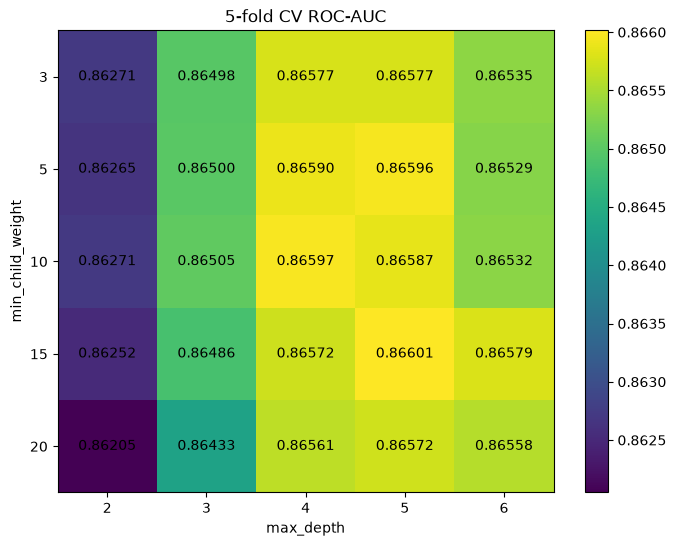


Train AUC: 0.8773046262139386
Test AUC: 0.8659906404732943
Gap: 0.011313985740644239


In [19]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

xgb_local = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    # zatím fixujeme nejlepší hodnoty z random search
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7
)

param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_child_weight': [3, 5, 10, 15, 20]
}

grid_search = GridSearchCV(
    estimator=xgb_local,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best CV AUC:", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)


# results dataframe
results = pd.DataFrame(grid_search.cv_results_)


# heatmap data
heatmap_data = results.pivot(
    index='param_min_child_weight',
    columns='param_max_depth',
    values='mean_test_score'
)

print("\nCV AUC heatmap data:")
print(heatmap_data)


# heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    heatmap_data.values,
    aspect='auto'
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel('max_depth')
ax.set_ylabel('min_child_weight')
ax.set_title('5-fold CV ROC-AUC')

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(
            j,
            i,
            f'{heatmap_data.iloc[i, j]:.5f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# nejlepší model na našem X_test
best_xgb = grid_search.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV AUC: 0.8661100578945226
Best parameters: {'gamma': 0.5, 'reg_lambda': 5}


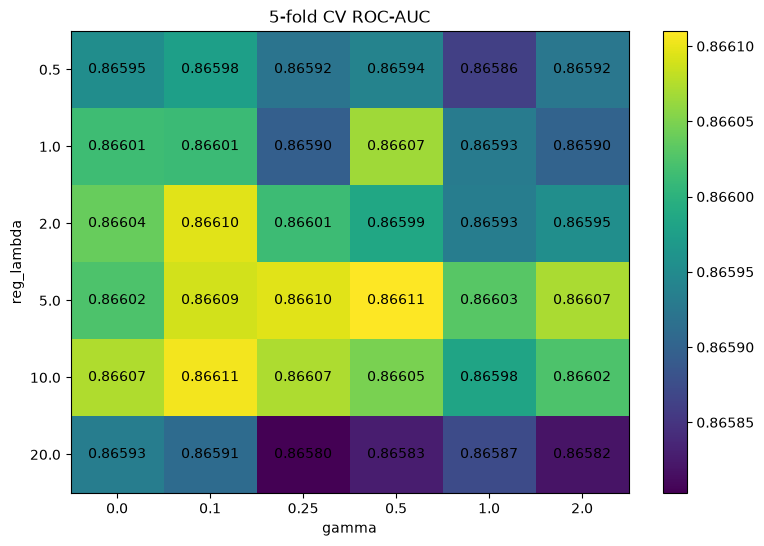

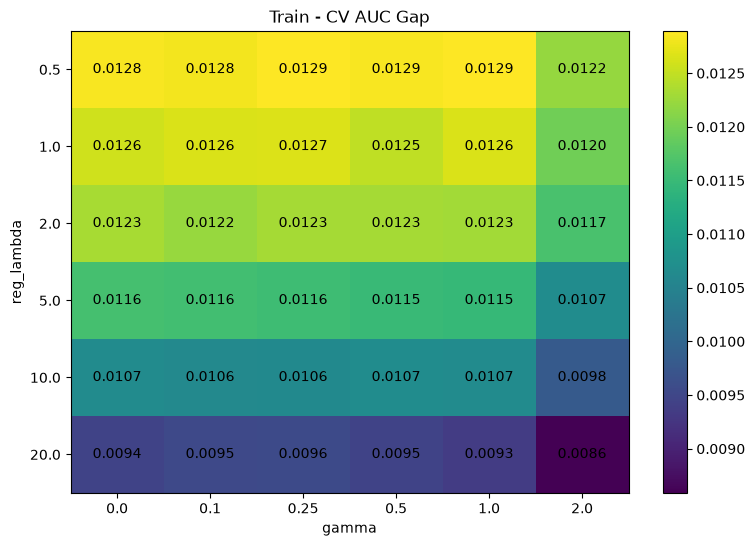


Train AUC: 0.8765478499478968
Test AUC: 0.8660006618566995
Gap: 0.010547188091197257


In [20]:
# regularization grid: gamma x reg_lambda

xgb_reg = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    # nejlepší hodnoty z předchozího gridu
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.7
)

param_grid = {
    'gamma': [0, 0.1, 0.25, 0.5, 1, 2],
    'reg_lambda': [0.5, 1, 2, 5, 10, 20]
}

grid_reg = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_reg.fit(X_train, y_train)


print("Best CV AUC:", grid_reg.best_score_)
print("Best parameters:", grid_reg.best_params_)


# výsledky
results = pd.DataFrame(grid_reg.cv_results_)

results['gap'] = (
    results['mean_train_score']
    - results['mean_test_score']
)


# -------------------------
# CV AUC heatmap
# -------------------------

auc_heatmap = results.pivot(
    index='param_reg_lambda',
    columns='param_gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    auc_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(auc_heatmap.columns)))
ax.set_xticklabels(auc_heatmap.columns)

ax.set_yticks(range(len(auc_heatmap.index)))
ax.set_yticklabels(auc_heatmap.index)

ax.set_xlabel('gamma')
ax.set_ylabel('reg_lambda')
ax.set_title('5-fold CV ROC-AUC')

for i in range(len(auc_heatmap.index)):
    for j in range(len(auc_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{auc_heatmap.iloc[i, j]:.5f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# Train - CV gap heatmap
# -------------------------

gap_heatmap = results.pivot(
    index='param_reg_lambda',
    columns='param_gamma',
    values='gap'
)

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    gap_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(gap_heatmap.columns)))
ax.set_xticklabels(gap_heatmap.columns)

ax.set_yticks(range(len(gap_heatmap.index)))
ax.set_yticklabels(gap_heatmap.index)

ax.set_xlabel('gamma')
ax.set_ylabel('reg_lambda')
ax.set_title('Train - CV AUC Gap')

for i in range(len(gap_heatmap.index)):
    for j in range(len(gap_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{gap_heatmap.iloc[i, j]:.4f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# nejlepší model na X_test
# -------------------------

best_xgb = grid_reg.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

In [21]:
# L1 regularization grid

xgb_alpha = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5
)

param_grid = {
    'reg_alpha': [0, 0.01, 0.05, 0.1, 0.25, 0.5, 1, 2, 5]
}

grid_alpha = GridSearchCV(
    estimator=xgb_alpha,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_alpha.fit(X_train, y_train)

print("Best CV AUC:", grid_alpha.best_score_)
print("Best parameters:", grid_alpha.best_params_)


results_alpha = pd.DataFrame(grid_alpha.cv_results_)

results_alpha['gap'] = (
    results_alpha['mean_train_score']
    - results_alpha['mean_test_score']
)

print(
    results_alpha[
        [
            'param_reg_alpha',
            'mean_train_score',
            'mean_test_score',
            'gap'
        ]
    ]
)


# nejlepší model na X_test

best_xgb = grid_alpha.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV AUC: 0.8661223428168452
Best parameters: {'reg_alpha': 0.01}
   param_reg_alpha  mean_train_score  mean_test_score       gap
0             0.00          0.877622         0.866110  0.011512
1             0.01          0.877609         0.866122  0.011486
2             0.05          0.877639         0.866095  0.011544
3             0.10          0.877561         0.866047  0.011514
4             0.25          0.877515         0.866030  0.011486
5             0.50          0.877514         0.866007  0.011507
6             1.00          0.877358         0.866102  0.011256
7             2.00          0.876886         0.866027  0.010859
8             5.00          0.875606         0.865894  0.009712

Train AUC: 0.8765443556732929
Test AUC: 0.8660002966329489
Gap: 0.010544059040344056


Fitting 5 folds for each of 49 candidates, totalling 245 fits
Best CV AUC: 0.8663180287448938
Best parameters: {'learning_rate': 0.01, 'n_estimators': 1000}

CV AUC HEATMAP:
param_learning_rate     0.010     0.020     0.030     0.040     0.050     0.075     0.100
param_n_estimators                                                                       
100                  0.860871  0.862772  0.863950  0.864636  0.865344  0.865607  0.865601
200                  0.862776  0.864785  0.865663  0.865744  0.866110  0.865186  0.864659
300                  0.863990  0.865621  0.866104  0.865864  0.865909  0.864492  0.863480
400                  0.864846  0.865959  0.866194  0.865670  0.865397  0.863552  0.862219
600                  0.865803  0.866153  0.865760  0.864884  0.864226  0.861773  0.859561
800                  0.866172  0.865924  0.865064  0.863894  0.862880  0.859702  0.857181
1000                 0.866318  0.865629  0.864381  0.862966  0.861653  0.857877  0.854785


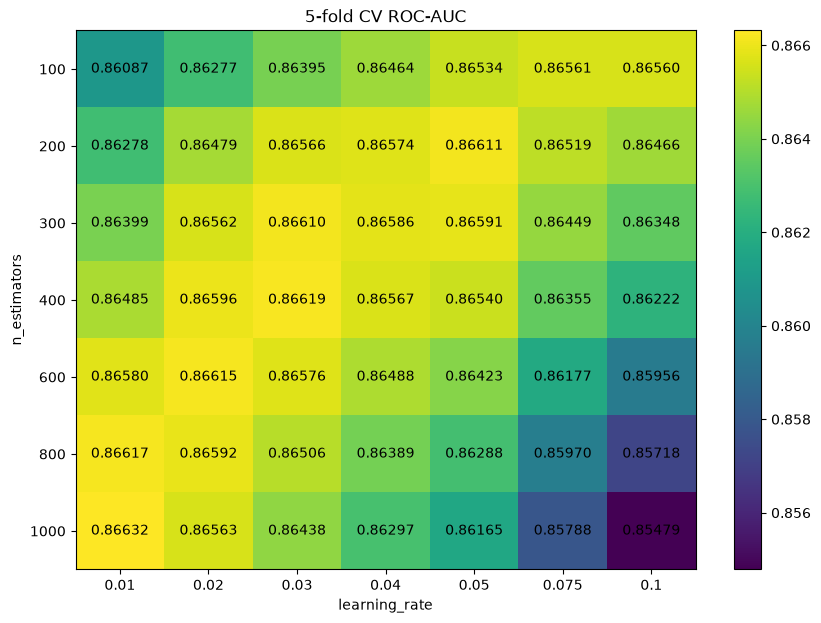


TRAIN - CV GAP HEATMAP:
param_learning_rate     0.010     0.020     0.030     0.040     0.050     0.075     0.100
param_n_estimators                                                                       
100                  0.003361  0.004330  0.005288  0.006559  0.007222  0.009410  0.011517
200                  0.004266  0.006355  0.008051  0.010189  0.011512  0.016033  0.019735
300                  0.005251  0.008189  0.010601  0.013423  0.015455  0.021464  0.026424
400                  0.006316  0.009964  0.013065  0.016614  0.019364  0.026488  0.032396
600                  0.008118  0.013088  0.017775  0.022319  0.026087  0.035021  0.043135
800                  0.009839  0.016306  0.022173  0.027604  0.032296  0.043075  0.052162
1000                 0.011463  0.019253  0.026123  0.032351  0.037834  0.050104  0.060663


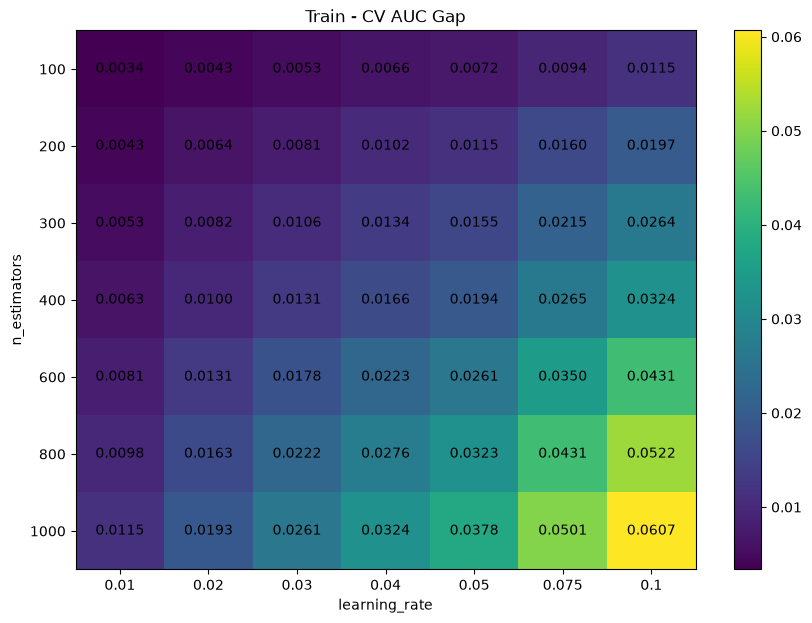


Train AUC: 0.8765739281362197
Test AUC: 0.8663746420695895
Gap: 0.010199286066630231


In [23]:
# learning_rate x n_estimators grid

xgb_lr = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    max_depth=5,
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0
)

param_grid = {
    'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.10],
    'n_estimators': [100, 200, 300, 400, 600, 800, 1000]
}

grid_lr = GridSearchCV(
    estimator=xgb_lr,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_lr.fit(X_train, y_train)

print("Best CV AUC:", grid_lr.best_score_)
print("Best parameters:", grid_lr.best_params_)


# results
results = pd.DataFrame(grid_lr.cv_results_)

results['gap'] = (
    results['mean_train_score']
    - results['mean_test_score']
)


# -------------------------
# CV AUC heatmap
# -------------------------

auc_heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_learning_rate',
    values='mean_test_score'
)

# vypis hodnot heatmapy
print("\nCV AUC HEATMAP:")
print(auc_heatmap.round(6).to_string())


fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    auc_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(auc_heatmap.columns)))
ax.set_xticklabels(auc_heatmap.columns)

ax.set_yticks(range(len(auc_heatmap.index)))
ax.set_yticklabels(auc_heatmap.index)

ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
ax.set_title('5-fold CV ROC-AUC')

for i in range(len(auc_heatmap.index)):
    for j in range(len(auc_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{auc_heatmap.iloc[i, j]:.5f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# Train - CV gap heatmap
# -------------------------

gap_heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_learning_rate',
    values='gap'
)

# vypis hodnot heatmapy
print("\nTRAIN - CV GAP HEATMAP:")
print(gap_heatmap.round(6).to_string())


fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    gap_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(gap_heatmap.columns)))
ax.set_xticklabels(gap_heatmap.columns)

ax.set_yticks(range(len(gap_heatmap.index)))
ax.set_yticklabels(gap_heatmap.index)

ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
ax.set_title('Train - CV AUC Gap')

for i in range(len(gap_heatmap.index)):
    for j in range(len(gap_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{gap_heatmap.iloc[i, j]:.4f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# nejlepší model na X_test
# -------------------------

best_xgb = grid_lr.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV AUC: 0.8663180287448938
Best parameters: {'learning_rate': 0.01, 'n_estimators': 1000}

CV AUC HEATMAP:
param_learning_rate    0.0050    0.0075    0.0100    0.0125    0.0150
param_n_estimators                                                   
800                  0.864835  0.865778  0.866172  0.866218  0.866254
1000                 0.865419  0.866114  0.866318  0.866186  0.866125
1200                 0.865790  0.866236  0.866313  0.866084  0.865924
1500                 0.866132  0.866315  0.866142  0.865748  0.865492
2000                 0.866310  0.866179  0.865736  0.865150  0.864671


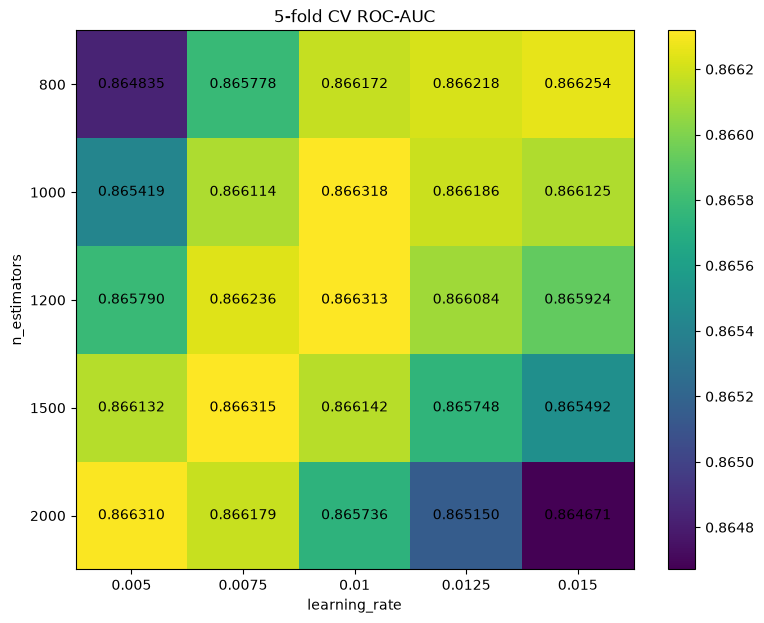


TRAIN - CV GAP HEATMAP:
param_learning_rate    0.0050    0.0075    0.0100    0.0125    0.0150
param_n_estimators                                                   
800                  0.006338  0.008200  0.009839  0.011520  0.013143
1000                 0.007296  0.009430  0.011463  0.013583  0.015545
1200                 0.008147  0.010707  0.013133  0.015549  0.017801
1500                 0.009423  0.012569  0.015611  0.018516  0.021126
2000                 0.011538  0.015632  0.019420  0.022962  0.026151


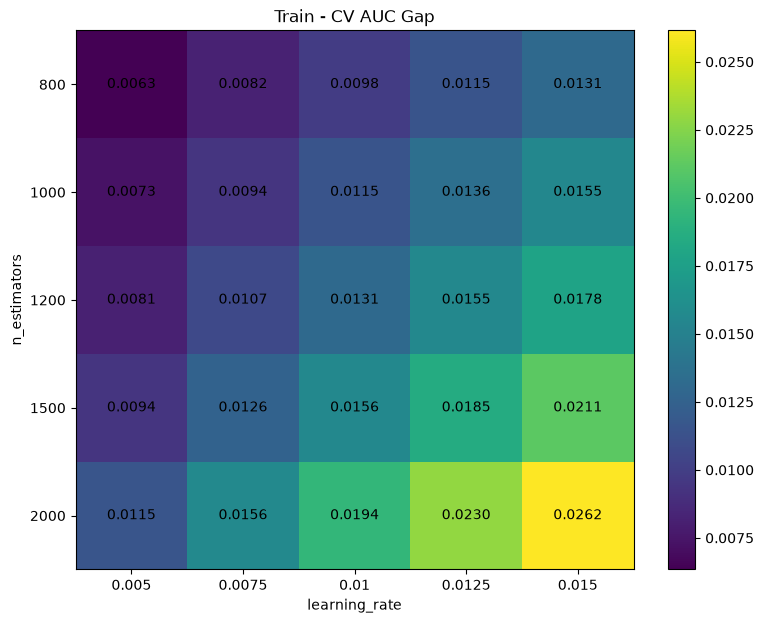


Train AUC: 0.8765739281362197
Test AUC: 0.8663746420695895
Gap: 0.010199286066630231


In [24]:
# local learning_rate x n_estimators grid

xgb_lr_local = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    max_depth=5,
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0
)

param_grid = {
    'learning_rate': [0.005, 0.0075, 0.01, 0.0125, 0.015],
    'n_estimators': [800, 1000, 1200, 1500, 2000]
}

grid_lr_local = GridSearchCV(
    estimator=xgb_lr_local,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_lr_local.fit(X_train, y_train)

print("Best CV AUC:", grid_lr_local.best_score_)
print("Best parameters:", grid_lr_local.best_params_)


# results
results = pd.DataFrame(grid_lr_local.cv_results_)

results['gap'] = (
    results['mean_train_score']
    - results['mean_test_score']
)


# -------------------------
# CV AUC heatmap
# -------------------------

auc_heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_learning_rate',
    values='mean_test_score'
)

print("\nCV AUC HEATMAP:")
print(auc_heatmap.round(6).to_string())


fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    auc_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(auc_heatmap.columns)))
ax.set_xticklabels(auc_heatmap.columns)

ax.set_yticks(range(len(auc_heatmap.index)))
ax.set_yticklabels(auc_heatmap.index)

ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
ax.set_title('5-fold CV ROC-AUC')

for i in range(len(auc_heatmap.index)):
    for j in range(len(auc_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{auc_heatmap.iloc[i, j]:.6f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# Train - CV gap heatmap
# -------------------------

gap_heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_learning_rate',
    values='gap'
)

print("\nTRAIN - CV GAP HEATMAP:")
print(gap_heatmap.round(6).to_string())


fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    gap_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(gap_heatmap.columns)))
ax.set_xticklabels(gap_heatmap.columns)

ax.set_yticks(range(len(gap_heatmap.index)))
ax.set_yticklabels(gap_heatmap.index)

ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
ax.set_title('Train - CV AUC Gap')

for i in range(len(gap_heatmap.index)):
    for j in range(len(gap_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{gap_heatmap.iloc[i, j]:.4f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# nejlepší model na X_test
# -------------------------

best_xgb = grid_lr_local.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

Zatim nejlepsi parametry modelu:

In [ ]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    max_depth=5,
    min_child_weight=15,

    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0,

    learning_rate=0.01,
    n_estimators=1000
)

Predikce pro kaggle test dataset

In [25]:
# FINAL XGBOOST -> KAGGLE SUBMISSION


# 1. Load data

training_data = pd.read_csv('../data/cs-training.csv')
kaggle_test = pd.read_csv('../data/cs-test.csv')
sample_submission = pd.read_csv('../data/sampleEntry.csv')


# 2. Features + target

X = training_data.drop(
    columns=['Unnamed: 0', 'SeriousDlqin2yrs'],
    errors='ignore'
)

y = training_data['SeriousDlqin2yrs']

X_kaggle = kaggle_test.drop(
    columns=['Unnamed: 0', 'SeriousDlqin2yrs'],
    errors='ignore'
)


# 3. Special late codes 96 / 98

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

X['special_late_code'] = (
    X[late_cols].isin([96, 98]).any(axis=1)
).astype(int)

X_kaggle['special_late_code'] = (
    X_kaggle[late_cols].isin([96, 98]).any(axis=1)
).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)
X_kaggle[late_cols] = X_kaggle[late_cols].replace([96, 98], 0)


# 4. Cap RevolvingUtilization na 2

X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)

X_kaggle['RevolvingUtilizationOfUnsecuredLines'] = (
    X_kaggle['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)


# 5. Invalid age = NaN

X['age'] = X['age'].replace(0, np.nan)
X_kaggle['age'] = X_kaggle['age'].replace(0, np.nan)


# 6. Income problem indicator
# MonthlyIncome samotný necháváme RAW

X['IncomeProblem'] = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
).astype(int)

X_kaggle['IncomeProblem'] = (
    X_kaggle['MonthlyIncome'].isna()
    | (X_kaggle['MonthlyIncome'] == 0)
).astype(int)


# kontrola, že train a Kaggle test mají stejné features

print("Train shape:", X.shape)
print("Kaggle test shape:", X_kaggle.shape)

print(
    "Same columns:",
    list(X.columns) == list(X_kaggle.columns)
)


# 7. Finální XGBoost

xgb_final = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    max_depth=5,
    min_child_weight=15,

    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0,

    learning_rate=0.01,
    n_estimators=1000
)


# 8. Train na CELÉM training datasetu

xgb_final.fit(X, y)


# 9. Predikce Kaggle test setu

kaggle_prob = xgb_final.predict_proba(X_kaggle)[:, 1]


# 10. Submission podle Kaggle sampleEntry.csv

submission = sample_submission.copy()

# první sloupec necháme tak, jak ho Kaggle dodal (ID)
# do druhého dáme naše pravděpodobnosti
submission.iloc[:, 1] = kaggle_prob


# 11. Save

submission.to_csv(
    '../data/submission_xgb.csv',
    index=False
)

print("\nSubmission preview:")
print(submission.head())

print("\nRows:", len(submission))
print("Probability min:", kaggle_prob.min())
print("Probability max:", kaggle_prob.max())

print("\nSaved as: ../data/submission_xgb.csv")

Train shape: (150000, 12)
Kaggle test shape: (101503, 12)
Same columns: True

Submission preview:
   Id  Probability
0   1     0.065499
1   2     0.049832
2   3     0.012548
3   4     0.081121
4   5     0.095676

Rows: 101503
Probability min: 0.0022943933
Probability max: 0.89511484

Saved as: ../data/submission_xgb.csv


Na Kaggle test setu dosáhl finální XGBoost model Private Score 0,86816 a Public Score 0,86189. Private score je pro srovnání s finálním pořadím soutěže důležitější, protože leaderboard se hodnotil podle neveřejné části testovacích dat. Výsledek je tak velmi blízko historickým vítězným řešením kolem 0,8695 AUC, tedy přibližně jen 0,0014 AUC za vítězným skóre. Zároveň dobře navazuje na interní 5-fold CV kolem 0,8663, takže model působí stabilně i mimo vlastní validační split.

On the Kaggle test set, the final XGBoost model achieved a Private Score of 0.86816 and a Public Score of 0.86189. The Private Score is more relevant for comparison with the final competition ranking, as the leaderboard was determined using the hidden portion of the test data. This places the model very close to the historical winning solutions at around 0.8695 AUC, only about 0.0014 AUC behind the top score. The result is also consistent with the internal 5-fold CV score of approximately 0.8663, suggesting that the model generalizes well beyond the validation split.